In [8]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
# Data Organization for Visualization
path = "/home/jinsu/project/sdofmv2/assets/ds_results/f107/"
df_sdofmv1 = pd.read_csv(path + "f107_results_sdofmv1.csv")
df_sdofmv1["timestamp"] = pd.to_datetime(df_sdofmv1["timestamp"], unit="ns")

# sdofmv2
df_sdofmv2_all = pd.read_csv(path + "f107_results_ALL.csv")
df_sdofmv2_all["timestamp"] = pd.to_datetime(df_sdofmv2_all["timestamp"], unit="ns")

# solaris
df_solaris = pd.read_csv(path + "test_results_solaris.csv")
df_solaris["date"] = pd.to_datetime(df_solaris["date"])

# f10.7 data
df_data = pd.read_csv("/home/jinsu/project/sdofmv2/assets/cache/f10.7.csv")

# inverse transformation of label/prediction
max_val = df_data[" f107"].max()
df_sdofmv1["label_denorm"] = df_sdofmv1["label"] * max_val
df_sdofmv1["prediction_denorm"] = df_sdofmv1["prediction"] * max_val

df_sdofmv2_all["label_denorm"] = df_sdofmv2_all["label"] * max_val
df_sdofmv2_all["prediction_denorm"] = df_sdofmv2_all["prediction"] * max_val

In [16]:
df_merge = df_sdofmv1.merge(df_sdofmv2_all, on="timestamp", how="inner", suffixes=("_v1", "_v2"))

In [17]:
df_merge

,timestamp,label_v1,prediction_v1,label_denorm_v1,prediction_denorm_v1,label_v2,prediction_v2,label_denorm_v2,prediction_denorm_v2
0,2010-10-01 00:00:00,0.236785,0.233868,86.900000,85.829557,0.236785,0.245942,86.900000,90.260822
1,2010-10-02 00:00:00,0.231880,0.241790,85.100002,88.736825,0.231880,0.230082,85.100002,84.440271
2,2010-10-03 00:00:00,0.218256,0.223356,80.100000,81.971770,0.218256,0.222863,80.100000,81.790646
3,2010-10-04 00:00:00,0.207357,0.217707,76.099999,79.898363,0.207357,0.224518,76.099999,82.398260
4,2010-10-05 00:00:00,0.205450,0.207269,75.400002,76.067821,0.205450,0.214692,75.400002,78.791985
...,...,...,...,...,...,...,...,...,...
655,2017-12-27 00:12:00,0.186921,0.202593,68.600002,74.351680,0.186921,0.197447,68.600002,72.463159
656,2017-12-28 00:12:00,0.187466,0.191632,68.799998,70.328907,0.187466,0.196262,68.799998,72.028177
657,2017-12-29 00:12:00,0.188283,0.193365,69.100002,70.964859,0.188283,0.200222,69.100002,73.481502
658,2017-12-30 00:12:00,0.185559,0.193664,68.100002,71.074835,0.185559,0.193036,68.100002,70.844159


In [ ]:
# df_merge = df_merge.merge(df_solaris, how="inner", left_on="timestamp", right_on="date")
df_merge = pd.merge_asof(df_merge, df_solaris, left_on="timestamp", right_on="date", tolerance=pd.Timedelta("12min"))
df_merge.dropna(subset=["date"], inplace=True)

In [25]:
df_merge

,timestamp,label_v1,prediction_v1,label_denorm_v1,prediction_denorm_v1,label_v2,prediction_v2,label_denorm_v2,prediction_denorm_v2,Unnamed: 0,date,target,prediction_raw,error
0,2010-10-01 00:00:00,0.236785,0.233868,86.900000,85.829557,0.236785,0.245942,86.900000,90.260822,NaN,NaT,NaN,NaN,NaN
1,2010-10-02 00:00:00,0.231880,0.241790,85.100002,88.736825,0.231880,0.230082,85.100002,84.440271,NaN,NaT,NaN,NaN,NaN
2,2010-10-03 00:00:00,0.218256,0.223356,80.100000,81.971770,0.218256,0.222863,80.100000,81.790646,1.0,2010-10-03,80.100000,88.166016,8.066016
3,2010-10-04 00:00:00,0.207357,0.217707,76.099999,79.898363,0.207357,0.224518,76.099999,82.398260,3.0,2010-10-04,76.099999,83.506836,7.406837
4,2010-10-05 00:00:00,0.205450,0.207269,75.400002,76.067821,0.205450,0.214692,75.400002,78.791985,5.0,2010-10-05,75.400002,81.714844,6.314842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,2017-12-27 00:12:00,0.186921,0.202593,68.600002,74.351680,0.186921,0.197447,68.600002,72.463159,1339.0,2017-12-27,68.600002,75.980469,7.380467
656,2017-12-28 00:12:00,0.187466,0.191632,68.799998,70.328907,0.187466,0.196262,68.799998,72.028177,1341.0,2017-12-28,68.799998,75.263672,6.463673
657,2017-12-29 00:12:00,0.188283,0.193365,69.100002,70.964859,0.188283,0.200222,69.100002,73.481502,1343.0,2017-12-29,69.100002,75.622070,6.522068
658,2017-12-30 00:12:00,0.185559,0.193664,68.100002,71.074835,0.185559,0.193036,68.100002,70.844159,1345.0,2017-12-30,68.100002,75.980469,7.880467


In [28]:
r2_sdofmv1 = r2_score(df_merge["target"], df_merge["prediction_denorm_v1"])
r2_sdofmv2_all = r2_score(df_merge["target"], df_merge["prediction_denorm_v2"])
r2_solaris = r2_score(df_merge["target"], df_merge["prediction_raw"])

mae_sdofmv1 = mean_absolute_error(df_merge["target"], df_merge["prediction_denorm_v1"])
mae_sdofmv2_all = mean_absolute_error(df_merge["target"], df_merge["prediction_denorm_v2"])
mae_solaris = mean_absolute_error(df_merge["target"], df_merge["prediction_raw"])

mse_sdofmv1 = mean_squared_error(df_merge["target"], df_merge["prediction_denorm_v1"])
mse_sdofmv2_all = mean_squared_error(df_merge["target"], df_merge["prediction_denorm_v2"])
mse_solaris = mean_squared_error(df_merge["target"], df_merge["prediction_raw"])

print(f"SDOFMV1, MAE: {mae_sdofmv1:.2f}, MSE: {mse_sdofmv1:.2f}, R-sqaured: {r2_sdofmv1:.4f}")
print(f"SDOFMV2_ALL, MAE: {mae_sdofmv2_all:.2f}, MSE: {mse_sdofmv2_all:.2f}, R-sqaured: {r2_sdofmv2_all:.4f}")
print(f"Solaris, MAE: {mae_solaris:.2f}, MSE: {mse_solaris:.2f}, R-sqaured: {r2_solaris:.4f}")


SDOFMV1, MAE: 8.13, MSE: 132.98, R-sqaured: 0.8698
SDOFMV2_ALL, MAE: 8.60, MSE: 138.84, R-sqaured: 0.8641
Solaris, MAE: 7.66, MSE: 134.02, R-sqaured: 0.8688


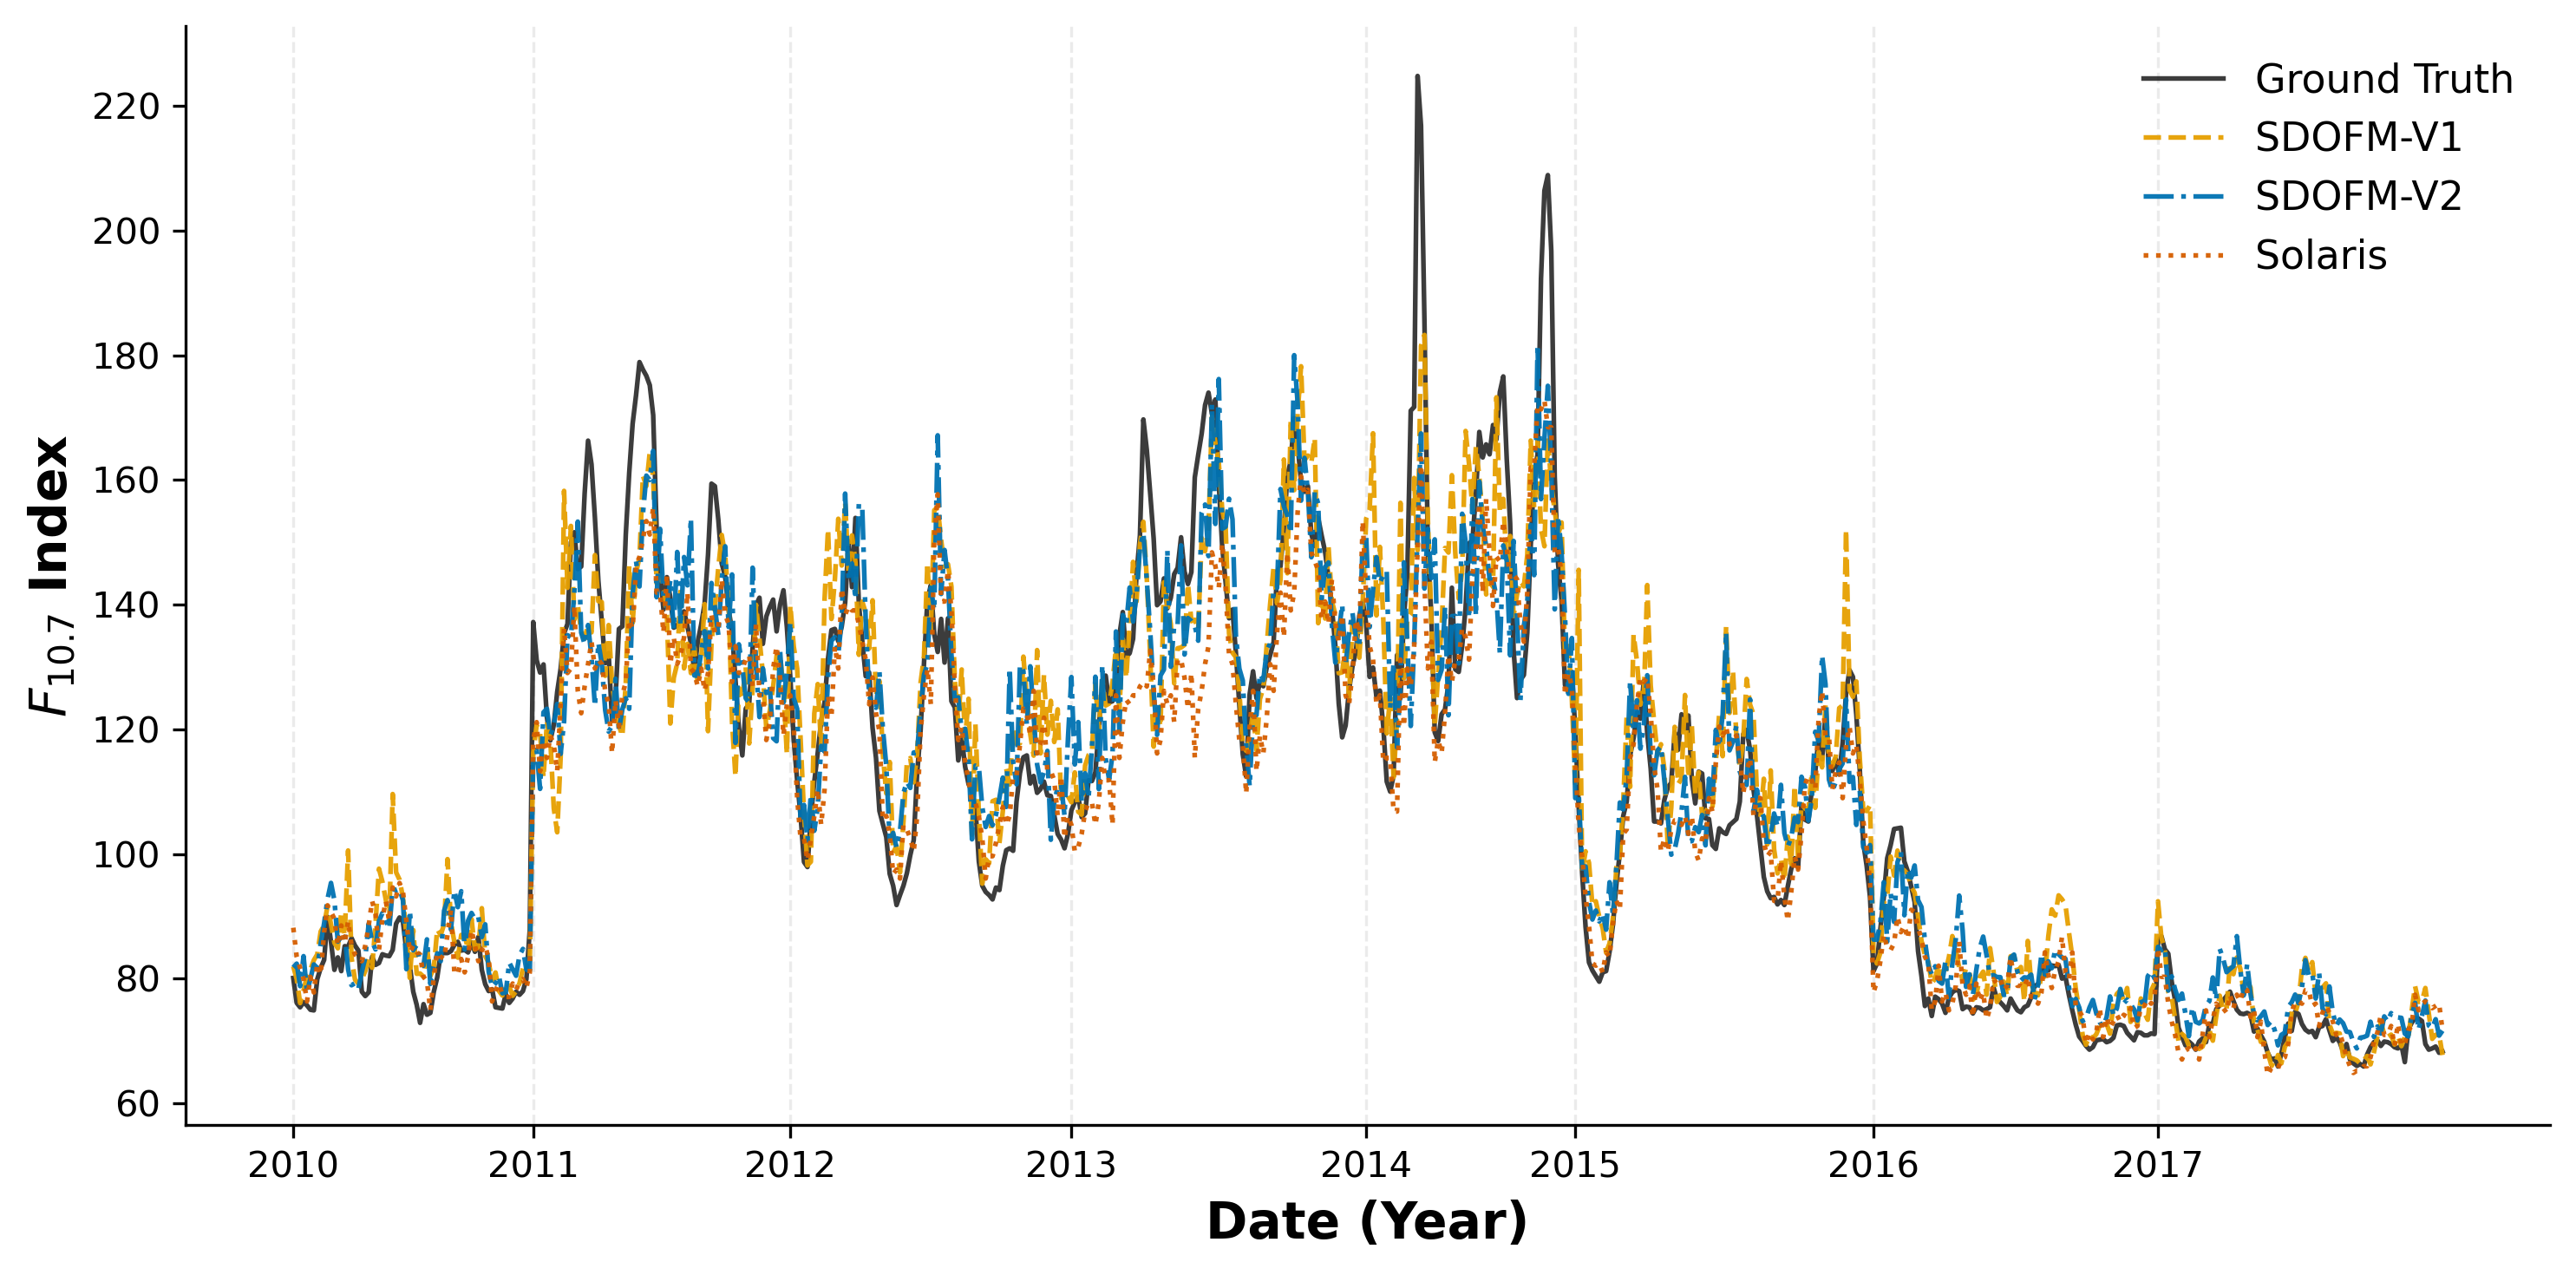

In [ ]:
dates = pd.to_datetime(df_merge["timestamp"])
years = dates.dt.year
x_v1 = np.arange(len(dates))

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth (strong reference)
ax.plot(
    x_v1, df_merge["target"],
    label="Ground Truth",
    color='#1a1a1a',
    linewidth=1.3,
    alpha=0.85
)

# SDOMF-V1 (Okabe-Ito Orange)
ax.plot(
    x_v1, df_merge["prediction_denorm_v1"],
    label="SDOFM-V1",
    color='#E69F00',
    linewidth=1.3,
    linestyle='--',
    alpha=0.95
)

# SDOMF-V2 (Okabe-Ito Blue)
ax.plot(
    x_v1, df_merge["prediction_denorm_v2"],
    label="SDOFM-V2",
    color='#0072B2',
    linewidth=1.3,
    linestyle='-.',
    alpha=0.95
)

# Solaris (replace neon green → muted red)
ax.plot(
    x_v1, df_merge["prediction_raw"],
    label="Solaris",
    color='#D55E00',
    linewidth=1.3,
    linestyle=':',
    alpha=0.95
)

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel(r"$F_{10.7}$ Index", fontsize=14, fontweight='bold')

unique_years, indices = np.unique(years, return_index=True)
ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

# Clean journal style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(True, axis='x', linestyle='--', alpha=0.25)

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()